# Miniature adaptive monotherapy screen: background ablation

Compare **lowest predicted LFC** with **2, 6, or 10 background cell lines** against a shared **random acquisition** baseline. More negative LFC means stronger killing; we seek the lowest, not largest absolute, responses.
- Pick the dose with the most response rows, average repeated screens, and randomly choose an eligible target cell line.
- Sample 10 other cell lines once. Use nested backgrounds: the first 2, first 6, and all 10. Every candidate compound must occur in at least one of the **first two** background lines, keeping coverage fixed across comparisons.
- Randomly limit this shared supported pool to 256 compounds. All runs use the same target, dose, pool, hit definition, and 16 initial target measurements, then reveal **8 compounds per round for 10 rounds**, refitting before each choice.
- Random acquisition ignores predictions, so a single seeded random trajectory serves all three background sizes.
- Hidden target responses are used only for revealing selected compounds and retrospective scoring. Background responses plus the initial 16 target responses train the first model; this is not a fit from only 16 total measurements.

**Retrieval metric:** fraction of the pool's lowest-LFC $\lceil 0.1N\rceil$ compounds discovered, including the initial 16. Ties are broken by compound ID. The hit set is fixed across runs and defined within this miniature pool, not all PRISM compounds. The x-axis counts target measurements only; historical background is excluded.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nbutils.batchie_mono.batchie import BayesianFixedDoseModel
from nbutils.batchie_mono.simulation import run_simulation
from nbutils.batchie_mono.batchie_selector import (
    PredictedLowestSelector,
    RandomSelector,
)

In [2]:
repo_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "pyproject.toml").exists() and (path / "data").is_dir()
)
data_path = repo_root / "data"
response_file = data_path / "secondary-screen-observed-response-long.parquet"
if not response_file.exists():
    raise FileNotFoundError(f"Response file does not exist: {response_file}")

keys = ["ModelID", "broad_id", "dose"]
responses = pd.read_parquet(response_file, columns=[*keys, "logfold_change"])
responses.head()

,ModelID,broad_id,dose,logfold_change
0,PR300_ACH-000001,BRD-K44408410-001-17-6,0.00061,0.164948
1,PR300_ACH-000001,BRD-K44408410-001-17-6,0.00244,-0.647867
2,PR300_ACH-000001,BRD-K44408410-001-17-6,0.03910,-0.241189
3,PR300_ACH-000001,BRD-K44408410-001-17-6,0.15625,0.176981
4,PR300_ACH-000001,BRD-K44408410-001-17-6,0.62500,-0.223823


## Experiment specifications

In [3]:
# impacts both cell line/compound selection and the actual model fitting
# fine for demo purpose nontheless
# the former experiments will have separate deterministic datasplitting independent of model fitting
seed = 0
rng = np.random.default_rng(seed)

# initial size means the number of compounds initially tested for the target model
# batch size is the number of compounds acquired adaptively in each iteration
# iterations is the total number of acquisition rounds
# with 16, 8, 10, the total number of compounds whose experimental truth will be revealed
# to BATCHIE will be 16 + 8 * 10 = 96
initial_size, batch_size, iterations = 16, 8, 10

# how many shared drugs to pool across multiple cell lines
pool_size = 256
background_counts = [2, 6, 10]

# Choose the best-covered dose; average repeated screens into one response key.
fixed_dose = responses.groupby("dose").size().idxmax()
fixed = (
    responses.loc[responses["dose"].eq(fixed_dose)]
    .dropna(subset=[*keys, "logfold_change"])
    .groupby(keys, as_index=False)["logfold_change"].mean()
)
coverage = fixed.groupby("ModelID")["broad_id"].nunique()
eligible = coverage[coverage >= initial_size + batch_size * iterations].index

# pick one of all cell lines selected as the final evaluation target
target_model = str(rng.choice(eligible))
# everything else becomes part of the background models (training data)
other_models = rng.choice(
    coverage.index[coverage.index != target_model],
    size=max(background_counts), replace=False,
)

# Use nested backgrounds and one pool supported by even the first two lines.
smallest_background = fixed[fixed["ModelID"].isin(other_models[:2])]
target_responses = fixed[
    fixed["ModelID"].eq(target_model)
    & fixed["broad_id"].isin(smallest_background["broad_id"])
]

# sample the target responses to match the pool size
# ground truth y which the model will never see but willtry to predict
target_responses = target_responses.sample(
    n=min(pool_size, len(target_responses)), random_state=seed
).reset_index(drop=True)

if not (len(target_responses) >= initial_size + batch_size * iterations):
    raise ValueError("Not enough target responses to match the required pool size.")

backgrounds = {
    count: fixed[
        fixed["ModelID"].isin(other_models[:count])
        & fixed["broad_id"].isin(target_responses["broad_id"])
    ].copy()
    for count in background_counts
}
initial_compounds = target_responses.sample(n=initial_size, random_state=seed)["broad_id"].tolist()

print(f"Target: {target_model} | fixed dose: {fixed_dose:g}")
print(f"\tBackground models: {other_models[:max(background_counts)]}")
print(f"Shared pool: {len(target_responses)} compounds | backgrounds: {background_counts}")
print(f"Shared initial observations: {initial_size} | acquisition: {iterations} × {batch_size}")

Target: PR500_ACH-000840 | fixed dose: 2.5
	Background models: ['PR500_ACH-000488' 'PR300_ACH-000202' 'PR500_ACH-000289'
 'PR300_ACH-000815' 'PR300_ACH-000992' 'PR300_ACH-000499'
 'PR300_ACH-000059' 'PR500_ACH-000787' 'PR300_ACH-000096'
 'PR500_ACH-000528']
Shared pool: 256 compounds | backgrounds: [2, 6, 10]
Shared initial observations: 16 | acquisition: 10 × 8


## Fitting BATCHIE + eval on target every iteration

In [4]:
runs = []
for count in background_counts:
    result = run_simulation(
        background=backgrounds[count],
        target_responses=target_responses,
        initial_compounds=initial_compounds,
        model=BayesianFixedDoseModel(seed=seed),
        selector=PredictedLowestSelector(),
        batch_size=batch_size,
        iterations=iterations,
    )
    result["background_cells"] = count
    result["background_measurements"] = len(backgrounds[count])
    runs.append(result)
    print(f"{count} background lines: retrieved {result.iloc[-1]['top_10pct_retrieval']:.1%} of top hits")

# Random selection ignores predictions so any background will yield the same trajectory 
# as we are sampling over the deterministic pool of compound names
random_baseline = run_simulation(
    background=backgrounds[2], # hard-coded for random baseline
    target_responses=target_responses,
    initial_compounds=initial_compounds,
    model=BayesianFixedDoseModel(seed=seed),
    selector=RandomSelector(seed=seed),
    batch_size=batch_size,
    iterations=iterations,
)
random_baseline["background_cells"] = 2
random_baseline["background_measurements"] = len(backgrounds[2])
metrics = pd.concat([*runs, random_baseline], ignore_index=True)
metrics.groupby(["selector", "background_cells"]).tail(1)

Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 5 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_

2 background lines: retrieved 96.2% of top hits


Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 6 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 6 seconds.
Chain 0 reached the maximum tree depth. Increase `

6 background lines: retrieved 96.2% of top hits


Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 4 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 8 seconds.
Chain 0 reached the maximum tree depth. Increase `

10 background lines: retrieved 100.0% of top hits


Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 4 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
Only 60 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [cell_offset_precision, dimension_precisions, compound_precisions, observation_precision, global_offset, cell_offsets, compound_offsets, cell_embeddings, compound_embeddings]
Sampling 1 chain for 40 tune and 60 draw iterations (40 + 60 draws total) took 4 seconds.
Chain 0 reached the maximum tree depth. Increase `

,selector,iteration,compounds_seen,top_hits_found,top_hits_total,top_10pct_retrieval,background_cells,background_measurements
10,predicted_lowest,10,96,25,26,0.961538,2,290
21,predicted_lowest,10,96,25,26,0.961538,6,644
32,predicted_lowest,10,96,26,26,1.000000,10,1198
43,random,10,96,8,26,0.307692,2,290


## Minimal sanity check results visualization

The plot uses circles (2), squares (6), and triangles (10) for background size, and crosses for random acquisition. Differences reflect added background information for this particular nested set, not a general guarantee about the number of cell lines needed.

As expected, BATCHIE does its job.

After being "trained" on 2, 6, or 10 background lines, BATCHIE demostrates far better than chance selectivity of lowest LFC (strongest killing effect) compounds on unseen cell lines.

Retrieves close to all top 10% killing compounds after seeing just 96 drugs (less than half) compared to random only retrieving 30%.

This is a sanity check demo that the minimal BATCHIE adaptation and implemenation works, to fully indicate superiority and utility we will need to place BATCHIE under stricter conditions like only seeing partial ground truth within each background cell lines and generalizing across tissue and cancer types. 
Also the bayesian sampling hyper-parameters needed to be tuned to ensure convergence (see outputs from PyMC and NUTS from cell 7 complaining that sampling is not sufficiently extensive).    

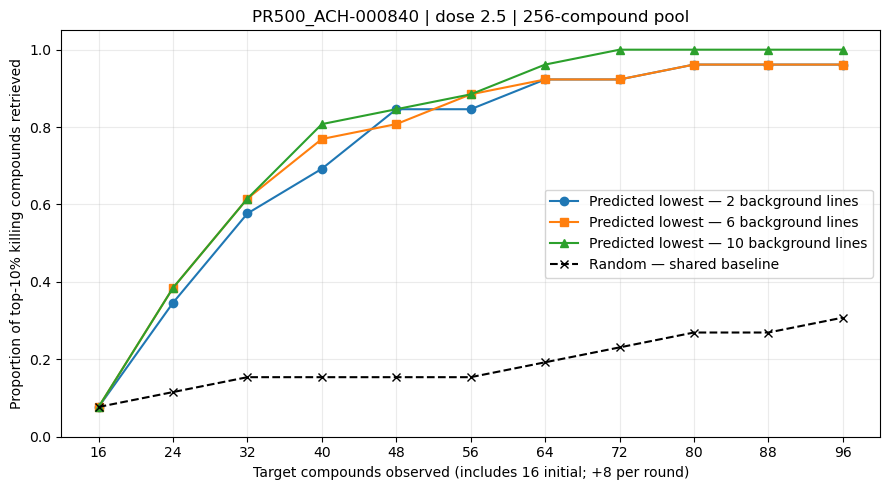

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
markers = {2: "o", 6: "s", 10: "^"}
predicted_metrics = metrics[metrics["selector"].eq("predicted_lowest")]
for count, trajectory in predicted_metrics.groupby("background_cells"):
    ax.plot(
        trajectory["compounds_seen"], trajectory["top_10pct_retrieval"],
        marker=markers[count], label=f"Predicted lowest — {count} background lines",
    )
ax.plot(
    random_baseline["compounds_seen"], random_baseline["top_10pct_retrieval"],
    color="black", linestyle="--", marker="x", label="Random — shared baseline",
)
ax.set(
    xlabel=f"Target compounds observed (includes {initial_size} initial; +{batch_size} per round)",
    ylabel="Proportion of top-10% killing compounds retrieved",
    title=f"{target_model} | dose {fixed_dose:g} | {len(target_responses)}-compound pool",
    ylim=(0, 1.05),
    xticks=random_baseline["compounds_seen"],
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()